# 前置き

- Pythonで書いてます．
- Pythonの文法を確認したい人は，以下のサイトを参考にしてください．
    - https://www.javadrive.jp/python/
    - https://www.tohoho-web.com/python/index.html
    - https://note.nkmk.me/python/
- CやJavaの{}を，Pythonはインデントで表します．インデントはTabキーで入れます．
    - 基本的にはJupyter側で適切にインデントを入れてくれるはずです．
- 普段はPythonを書かない人間がPythonで書いていますので，Pythonらしくない書き方があるかもしれません．

# ファジィ制御の実装を見てみる

ファジィ制御で何が行われるかを知るには「チップ問題」がよく例として挙げられるそうです．

日本にはチップの習慣はありませんが，国によっては，サービスへの対価としてチップを支払う習慣があります．

ここでは，

- レストランで自分の席を担当したスタッフのサービスがよかったかどうか
- 提供された食事のクオリティはどうだったか

という評価項目から，**「チップをいくら支払うか？」**をファジィ制御で求めます．


**プログラム例を出しながら解説しますので，順番に読み進めてください．**

**これを読み終えたら，実際にプログラムを書いてもらいます．**

## ファジィルールの形

チップ問題でのファジィルールは，以下のような形となります．

> IF "service is ○○" AND "food quality is △△" THEN "tip is ☆☆"

前件部変数は2つ，後件部変数は1つです．

"service is ○○" は，スタッフのサービスが良かったかどうかを指します．値は0から10で表します．

"food quality is △△" は，食事のクオリティがどうだったかを指します．値は0から10で表します．

"tip is ☆☆" は，食事の金額の何%をチップとして支払うかを指します．0%から25%の割合で表します．

## 三角型メンバーシップ関数の形

### 前件部 サービスに対応する三角型メンバーシップ関数

サービスに対応する三角型メンバーシップ関数は以下のような形とします．

メンバーシップ関数のグラフが見えない場合には，pythonのコードが書かれているセルで，`Shift + Enter` を押してください．

ファジィラベルは以下のことを意味します．

- poor：不十分
- acceptable：満足
- amazing：すばらしい

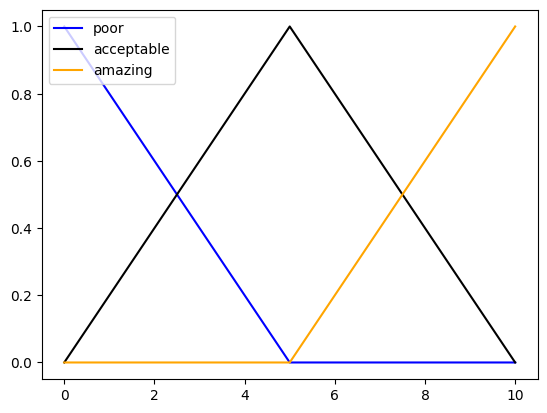

In [1]:
%matplotlib inline

# サービスのメンバーシップ関数を描画する
import numpy as np
import matplotlib.pyplot as plt
 
# 台集合
supset = np.array([0, 5, 10])

# ファジィラベル poor
poor = np.array([1, 0, 0])
plt_poor = plt.plot(supset, poor, color="blue") # plt.plot()で描画

# ファジィラベル acceptable
acceptable = np.array([0, 1, 0])
plt_acceptable = plt.plot(supset, acceptable, color="black")

# ファジィラベル amazing
amazing = np.array([0, 0, 1])
plt_amazing = plt.plot(supset, amazing, color="orange")

# 凡例の表示
plt.legend((plt_poor[0], plt_acceptable[0], plt_amazing[0]), ("poor", "acceptable", "amazing"), loc=2)

# Shift + Enter を押してもグラフが表示されないときは，もう一度 Shift + Enter を押す

### 前件部 食事のクオリティに対応する三角型メンバーシップ関数

食事のクオリティに対応する三角型メンバーシップ関数は以下の形です．
メンバーシップ関数のグラフが見えない場合には，pythonのコードが書かれているセルで，`Shift + Enter` を押してください．

ファジィラベルは以下のことを意味します．

- bad：悪い
- decent：満足できる
- great：すばらしい

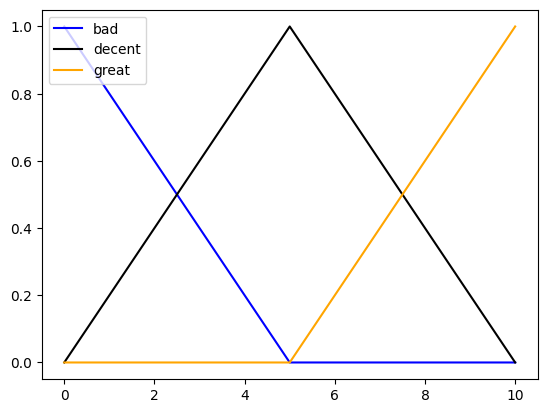

In [2]:
%matplotlib inline

# 食事のクオリティのメンバーシップ関数を描画する
import numpy as np
import matplotlib.pyplot as plt
 
# 台集合
supset = np.array([0, 5, 10])

# ファジィラベル bad
bad = np.array([1, 0, 0])
plt_bad = plt.plot(supset, bad, color="blue")

# ファジィラベル decent
decent = np.array([0, 1, 0])
plt_decent = plt.plot(supset, decent, color="black")

# ファジィラベル great
great = np.array([0, 0, 1])
plt_great = plt.plot(supset, great, color="orange")

# 凡例の表示
plt.legend((plt_bad[0], plt_decent[0], plt_great[0]), ("bad", "decent", "great"), loc=2)

### 後件部 チップの割合に対応する三角型メンバーシップ関数

チップの割合に対応する三角型メンバーシップ関数は以下の形です．
メンバーシップ関数のグラフが見えない場合には，pythonのコードが書かれているセルで，`Shift + Enter` を押してください．

ファジィラベルは以下のことを意味します．

- low：低い
- medium：並み
- high：高い

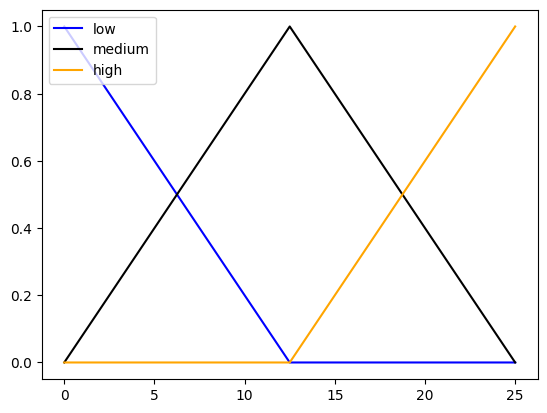

In [3]:
%matplotlib inline

# チップの割合のメンバーシップ関数を描画する
import numpy as np
import matplotlib.pyplot as plt
 
supset = np.array([0, 12.5, 25])

low = np.array([1, 0, 0])
plt_low = plt.plot(supset, low, color="blue")

medium = np.array([0, 1, 0])
plt_medium = plt.plot(supset, medium, color="black")

high = np.array([0, 0, 1])
plt_high = plt.plot(supset, high, color="orange")

plt.legend((plt_low[0], plt_medium[0], plt_high[0]), ("low", "medium", "high"), loc=2)

### ファジィルール

チップ問題のファジィルールは以下の3つです．

- IF "service is poor" AND "food quality is bad" THEN "tip is low"
- IF "service is acceptable" THEN "tip is medium"
- IF "service is amazing" AND "food quality is great" THEN "tip is high"

## ファジィ制御の実装

### 前件部 サービスのメンバーシップ値を求める関数を準備する

まず，ルール前件部の「サービス」のメンバーシップ値を求める関数を準備します．

サービスの評価値（0から10の値）から，各ファジィ集合（poor, acceptable, amazing）に対するメンバーシップ値を求めます．

プログラムで書くと以下のようになります．

各セルを順番に，`Shift + Enter`で実行してみてください．

In [ ]:
def mf_of_service(x):
    """ サービスの評価値（0から10の値）から，サービスに対応する各ファジィ集合（poor, acceptable, amazing）のメンバーシップ値を計算する．
    
    Args:
        x: サービスの評価値．0から10の値を取る．
        
    Returns:
        辞書型の戻り値．keyは各ファジィラベル，valueは引数xに対する各ファジィ集合（poor, acceptable, amazing）のメンバーシップ値．
    
    """
    
    # 変数を初期化する
    poor = acceptable = amazing = None
    
    # ここで各メンバーシップ関数の値を計算する（if-elseを三項演算子で書いている）
    ## poorに対するメンバーシップ値
    poor = 0.0 if x >= 5.0 else -0.2 * x + 1.0
    
    ## acceptableに対するメンバーシップ値
    acceptable = 0.2 * x if x <= 5.0 else -0.2 * (x - 5.0) + 1.0
    
    ## amazingに対するメンバーシップ値
    amazing = 0.0 if x <= 5.0 else 0.2 * (x - 5.0)
    
    return {'poor':poor, 'acceptable':acceptable, 'amazing':amazing}

# Shift + Enter でプログラムを実行してください
# 定義しているだけなので，実行しても何も出力されないです

三項演算子の書き方は以下のとおりです．

```python
条件式がTrueのときに行う処理 if 条件式 else 条件式がFalseのときに行う処理
```

これは，以下の書き方と同じことをしています．

```python
if 条件式:
    条件式がTrueのときに行う処理
else:
    条件式がFalseのときに行う処理
```

では，実際にメンバーシップ値が求められるかどうかを確認します．

In [18]:
# サービスの評価値を9.8とする
service = mf_of_service(9.8)

print("サービスに対するメンバーシップ値")
print("ファジィラベル poor ： ", service['poor']) # 辞書型変数はキー指定で値を参照できる
print("ファジィラベル acceptable ： ", service['acceptable'])
print("ファジィラベル amazing ： ", service['amazing'])

サービスに対するメンバーシップ値
ファジィラベル poor ：  0.0
ファジィラベル acceptable ：  0.039999999999999813
ファジィラベル amazing ：  0.9600000000000002


これをグラフで表すと，以下のようになります．`shift + enter` で次のセルを実行し，グラフを描画してください．

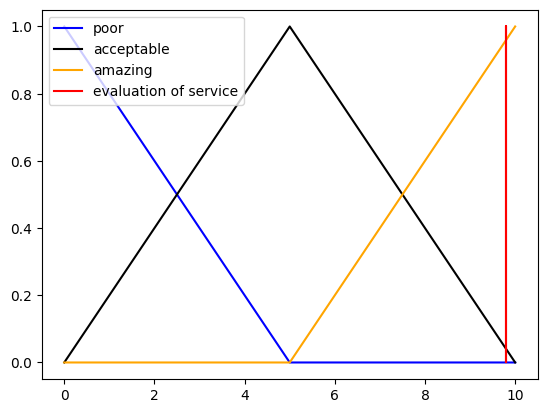

In [6]:
%matplotlib inline

# サービスのメンバーシップ関数を描画する
import numpy as np
import matplotlib.pyplot as plt
 
supset = np.array([0, 5, 10])

poor = np.array([1, 0, 0])
plt_poor = plt.plot(supset, poor, color="blue")

acceptable = np.array([0, 1, 0])
plt_acceptable = plt.plot(supset, acceptable, color="black")

amazing = np.array([0, 0, 1])
plt_amazing = plt.plot(supset, amazing, color="orange")

# サービスの評価値9.8をプロット
plt_eval = plt.plot([9.8, 9.8, 9.8], [0, 1, 0], color="red")

# 凡例の表示
plt.legend((plt_poor[0], plt_acceptable[0], plt_amazing[0], plt_eval[0]), ("poor", "acceptable", "amazing", "evaluation of service"), loc=2)

サービスに対する評価が9.8のとき，poor，acceptable，amazing とそれぞれ交わっているところが各ファジィ集合に対するメンバーシップ値になっているのがわかるかと思います．

### 前件部 食事のクオリティのメンバーシップ値を求める関数を準備する

次に，ルール前件部の「食事のクオリティ」のメンバーシップ値を求める関数を準備します．

評価値（0から10の値）から，各ファジィ集合（bad, decent, great）に対するメンバーシップ値を求めます．

プログラムで書くと以下のようになります．

各セルを順番に，`Shift + Enter`で実行してみてください．

In [7]:
def mf_of_quality(x):
    """ 食事のクオリティの評価値（0から10の値）から，対応する各ファジィ集合（bad, decent, great）のメンバーシップ値を計算する．
    
    Args:
        x: 食事のクオリティの評価値．0から10の値を取る．
        
    Returns:
        辞書型の戻り値．keyは各ファジィ集合のラベル，valueは引数xに対する各ファジィ集合（bad, decent, great）のメンバーシップ値．
    
    """
    
    # 変数を初期化する
    bad = decent = great = None
    
    # ここで各メンバーシップ関数の値を計算する
    ## badに対するメンバーシップ値
    bad = 0.0 if x >= 5.0 else -0.2 * x + 1.0
    
    ## decentに対するメンバーシップ値
    decent = 0.2 * x if x <= 5.0 else -0.2 * (x - 5.0) + 1.0
    
    ## greatに対するメンバーシップ値
    great = 0.0 if x <= 5.0 else 0.2 * (x - 5.0)
    
    return {'bad':bad, 'decent':decent, 'great':great}

# Shift + Enter でプログラムを実行してください

In [8]:
# 食事のクオリティの評価値を6.5とする
quality = mf_of_quality(6.5)

print("食事のクオリティに対するメンバーシップ値")
print("ファジィラベル bad ： ", quality['bad']) # 辞書型変数はキー指定で値を参照できる
print("ファジィラベル decent ： ", quality['decent'])
print("ファジィラベル great ： ", quality['great'])

食事のクオリティに対するメンバーシップ値
ファジィラベル bad ：  0.0
ファジィラベル decent ：  0.7
ファジィラベル great ：  0.30000000000000004


サービスに対するメンバーシップ値と同様に，グラフで表してみます．

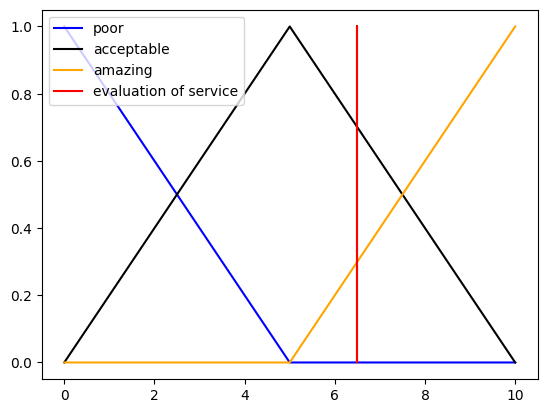

In [9]:
%matplotlib inline

# 食事のクオリティのメンバーシップ関数を描画する
import numpy as np
import matplotlib.pyplot as plt
 
supset = np.array([0, 5, 10])

bad = np.array([1, 0, 0])
plt_bad = plt.plot(supset, bad, color="blue")

decent = np.array([0, 1, 0])
plt_decent = plt.plot(supset, decent, color="black")

great = np.array([0, 0, 1])
plt_great = plt.plot(supset, great, color="orange")

# 食事のクオリティの評価値6.5をプロット
plt_eval = plt.plot([6.5, 6.5, 6.5], [0, 1, 0], color="red")

# 凡例の表示
plt.legend((plt_poor[0], plt_acceptable[0], plt_amazing[0], plt_eval[0]), ("poor", "acceptable", "amazing", "evaluation of service"), loc=2)

### 後件部 チップの割合に対応するメンバーシップ値を求める関数を準備する

ルール前件部と同じように，ルール後件部の「チップの割合」のメンバーシップ値を求める関数を準備します．

割合（0%から25%の値）から，各ファジィ集合（low, medium, high）に対するメンバーシップ値を求めます．

プログラムで書くと以下のようになります．

各セルを順番に，`Shift + Enter`で実行してみてください．

In [10]:
def mf_of_tip(x):
    """ チップの割合（0%から25%の値）から，対応する各ファジィ集合（low, medium, high）のメンバーシップ値を計算する．
    
    Args:
        x: チップの割合．0から25の値を取る．
        
    Returns:
        辞書型の戻り値．keyは各ファジィ集合のラベル，valueは引数xに対する各ファジィ集合（low, medium, high）のメンバーシップ値．
    
    """
    
    # 変数を初期化する
    low = medium = high = None
    
    # ここで各メンバーシップ関数の値を計算する
    ## lowに対するメンバーシップ値
    low = 0.0 if x >= 12.5 else -0.08 * x + 1.0
    
    ## mediumに対するメンバーシップ値
    medium = 0.08 * x if x<= 12.5 else -0.08 * (x - 12.5) + 1.0
    
    ## highに対するメンバーシップ値
    high = 0.0 if x <= 12.5 else 0.08 * (x - 12.5)
    
    return {'low':low, 'medium':medium, 'high':high}

# Shift + Enter でプログラムを実行してください

In [11]:
# mf_of_tip() でメンバーシップ値が求められたかどうか確認したい場合は，このセルを使ってください．

# 確認するためのプログラムを書いて，Shift + Enter で実行する


ここまでで，ファジィ制御に必要となる，前件部と後件部の三角型メンバーシップ関数が準備できました．

### 各ファジィルールの結論を求めるために，後件部を離散化する

ファジィ制御を実装する場合，紙の上での計算と違う点があります．それが，各ファジィルールの後件部の離散化です．

ファジィ制御では，結論（出力）は確定値であるため，非ファジィ化が必要です．

コンピュータ上で非ファジィ化をするには，結論のファジィ集合を離散値にしないと計算ができません．

配列を使うことで，ファジィ集合の離散化が可能です．ここでは，numpyという数値計算用のモジュールをインポートし，numpy配列でファジィ集合を離散化します．

In [12]:
# numpyをインポートし，npという名前で扱えるようにする
import numpy as np

# 各ファジィ集合のメンバーシップ値を格納するnumpy配列を初期化する
# 51なのは，要素であるチップの割合を0.5刻みの値で扱うため
low = np.zeros(51)
medium = np.zeros(51)
high = np.zeros(51)

# チップの割合を0.5刻みでnumpy配列として用意する
tip_support =  np.arange(0, 25.5, 0.5)

# チップの割合のファジィ集合に対応するnumpy配列に，メンバーシップ値を格納する
for i in range(51):
    low[i] = mf_of_tip(tip_support[i])['low']
    medium[i] = mf_of_tip(tip_support[i])['medium']
    high[i] = mf_of_tip(tip_support[i])['high']

# 今後のために辞書型の変数に格納しておく
tip = {'low':low, 'medium':medium, 'high':high}
    
    
# 各ファジィ集合にメンバーシップ値が格納されたかの確認
# 辞書型の変数にしておくことで，ファジィ集合名で値を返すことができる
print("ファジィ集合 low")
print(tip['low'])

print("ファジィ集合 medium")
print(tip['medium'])

print("ファジィ集合 high")
print(tip['high'])

ファジィ集合 low
[1.   0.96 0.92 0.88 0.84 0.8  0.76 0.72 0.68 0.64 0.6  0.56 0.52 0.48
 0.44 0.4  0.36 0.32 0.28 0.24 0.2  0.16 0.12 0.08 0.04 0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
ファジィ集合 medium
[0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   0.96 0.92
 0.88 0.84 0.8  0.76 0.72 0.68 0.64 0.6  0.56 0.52 0.48 0.44 0.4  0.36
 0.32 0.28 0.24 0.2  0.16 0.12 0.08 0.04 0.  ]
ファジィ集合 high
[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.08
 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52 0.56 0.6  0.64
 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.  ]


### 各ファジィルールについて，結論を求める

ここまでで，ファジィルールの前件部と後件部のファジィ集合の準備ができました．

次に，1つのファジィルールから結論を求める関数を定義します．

In [13]:
def rule(*args, arg1):
    """ ひとつのファジィルールについて，結論を求める．
    
    Args:
        *args: ファジィルール前件部のメンバーシップ値．可変長引数という仕組みを使っていて，引数をいくつでも与えることができる．
        arg1: ファジィルール後件部の離散化したファジィ集合．引数の最後は必ず後件部のファジィ集合でなければいけない．
        
    Returns:
        結論のメンバーシップ値をnumpy配列で返す．
    
    """
    
    # 前件部のメンバーシップ値のandを取る．入力は確定値なので，値が1つ得られる．
    # antecedent は前件部という意味
    # args には，引数として与えた前件部のファジィ集合がすべて含まれている
    antecedent = min(args)
    
    # antecedentと後件部とでandをとった結果が結論となる
    # arg1 は，引数として与えた後件部のファジィ集合（numpy配列）
    # np.where()を使うことで，antecedentと後件部numpy配列のandを取れる（もちろん，forループなどを使って地道に書いてもよい）
    result = np.where(arg1 <= antecedent, arg1, antecedent)
    
    return result

`np.where` というのは，numpy配列に対して，条件に応じた処理をする関数です．

`np.where(condition, x, y)` という書き方で，条件conditionを満たす場合はx，そうでない場合はyとして，numpy配列を返します．

上記のプログラムでは，後件部のメンバーシップ値がantecedent以下であれば後件部のメンバーシップ値を，そうでなければantecedentのメンバーシップ値をnumpy配列の要素として返しています．

つまり，antecedent で，離散化した後件部のファジィ集合の頭切りをしているわけです．

では，実際に，チップ問題のファジィルールを与えて結論を求めます．

- IF "service is poor" AND "food quality is bad" THEN "tip is low"
- IF "service is acceptable" THEN "tip is medium"
- IF "service is amazing" AND "food quality is great" THEN "tip is high"

In [14]:
# チップ問題のファジィルールを与えて，結論をprintで表示する

print("IF \"service is poor\" AND \"food quality is bad\" THEN \"tip is low\"")
rule1 = rule(service['poor'], quality['bad'], arg1=tip['low'])
print(rule1)

print("IF \"service is acceptable\" THEN \"tip is medium\"")
rule2 = rule(service['acceptable'], arg1=tip['medium'])
print(rule2)

print("IF \"service is amazing\" AND \"food quality is great\" THEN \"tip is high\"")
rule3 = rule(service['amazing'], quality['great'], arg1=tip['high'])
print(rule3)

IF "service is poor" AND "food quality is bad" THEN "tip is low"
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
IF "service is acceptable" THEN "tip is medium"
[0.   0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.  ]
IF "service is amazing" AND "food quality is great" THEN "tip is high"
[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.08
 0.12 0.16 0.2  0.24 0.28 0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3
 0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3 ]


### 各ファジィルールの結論をまとめる

ここまでで，各ファジィルールについて結論を求めることができました．

次に，各結論をまとめます．まとめるにはOR結合を行います．

numpyの便利な関数を使うと，numpy配列に格納してあるメンバーシップ値に対して，一気にorを取ることができます．

In [15]:
# 確認のためにもう一度，各ルールの結論を表示する
print('rule1: ', rule1)
print('rule2: ', rule2)
print('rule3: ', rule3)

# 各結論をOR結合する
# np.maximum() は2つのnumpy配列に対してしか使えないが，reduce()を使うことで，rule1とrule2のOR結合をしてから，rule3とのOR結合ができる
# 詳しくは，https://note.nkmk.me/python-numpy-maximum-minimum-fmax-fmin/ を読むとよい
result = np.maximum.reduce([rule1, rule2, rule3])

# OR結合でまとめた結論を表示する
print('OR結合の結果')
print(result)

rule1:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
rule2:  [0.   0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.  ]
rule3:  [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.08
 0.12 0.16 0.2  0.24 0.28 0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3
 0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3 ]
OR結合の結果
[0.   0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04
 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.08
 0.12 0.16 0.2  0.24 0.28 0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3
 0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3  0.3 ]


### 非ファジィ化して，出力する値を求める

ここまでで，結論のファジィ集合が求まりました．

ファジィ推論ならここで終わりですが，ファジィ制御では最終的にひとつの数値を出力しなければなりません．

そのために，非ファジィ化を行います．

非ファジィ化には様々な方法がありますが，ここでは重心法を使います．

以下は重心法で非ファジィ化を行う関数です．

In [16]:
def defuzzy(fs):
    """ 結論として求められたファジィ集合に対して，非ファジィ化を行う．重心法で計算する．
    
    Args:
        fs: 各結論をOR結合して求められた結論．numpy配列で与えられる．
        
    Returns:
        重心法で非ファジィ化した値
    
    """

    num = 0.0
    den = 0.0
    size = 0.0 # チップの値を表す
    
    for x in fs:
        num = num + x * size
        den = den + x
        size = size + 0.5 # 離散化するときに0.5刻みにしたので，0.5ずつ加えていく
     
    center = num / den if den != 0.0 else 0.0

    return center

それでは，非ファジィ化した結果を見てみましょう．

ここまで，あなたがプログラムに変更を加えていなければ，

- サービスの評価値は 9.8
- 食事のクオリティの評価値は 6.5 

という入力に対して，`17.998670212765976` が求められるはずです．これが支払うチップの割合になります．

In [17]:
print('非ファジィ化の結果：')
print(defuzzy(result))

非ファジィ化の結果：
17.998670212765976


入力となる，サービスの評価値，食事のクオリティの評価値が変わると，非ファジィ化の結果も変わってくるはずです．

本当に変わるのか気になる人は，該当するセルの内容を書き換えて実行し，確認してみてください．